In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../etl/diabetic_data_clean.csv")

## Estabilidad del tratamiento vs el Reingreso

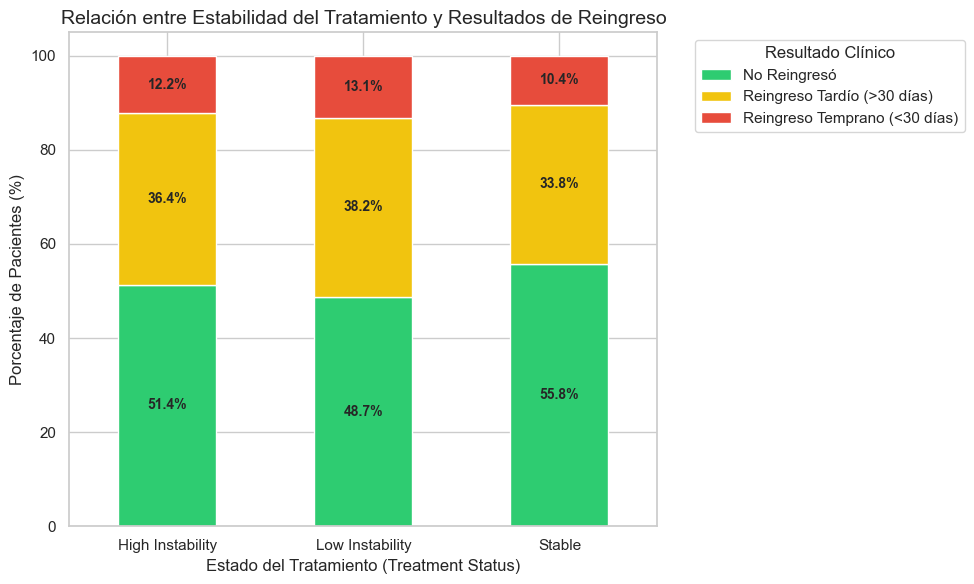

In [4]:
# Configuramos el estilo
sns.set_theme(style="whitegrid")

# Creamos un gráfico de barras apiladas al 100% (Normalizado)
# para ver la proporción de reingresos por tipo de tratamiento
analysis_df = pd.crosstab(df['treatment_status'], df['readmitted_status'], normalize='index') * 100

# Graficamos
ax = analysis_df.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#2ecc71', '#f1c40f', '#e74c3c'])

plt.title('Relación entre Estabilidad del Tratamiento y Resultados de Reingreso', fontsize=14)
plt.xlabel('Estado del Tratamiento (Treatment Status)', fontsize=12)
plt.ylabel('Porcentaje de Pacientes (%)', fontsize=12)
plt.legend(title='Resultado Clínico', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

# Añadimos etiquetas de porcentaje dentro de las barras
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()

Eje x: divide los pacienes por su estado de tratamiento
EJe y: muesra el porcentaje de pacientes

Hallazgo: los pacientes con tratamiento stable tienen una mayor taza de exito y no vuelve al hospital, mientras que los pacientes con mayor inestabilidad tienen mayor posibilidad de regresar.

Este gráfico confirma que cuando logramos que el tratamiento no cambie (estable), el paciente tiene mejores resultados. Si hay mucha inestabilidad, el porcentaje de "No Reingreso" baja casi 7 puntos, aumentando especialmente el riesgo de tener que volver después del mes.

## Principales Causas de INgresos Hospitalarios por Pacientes Unicos

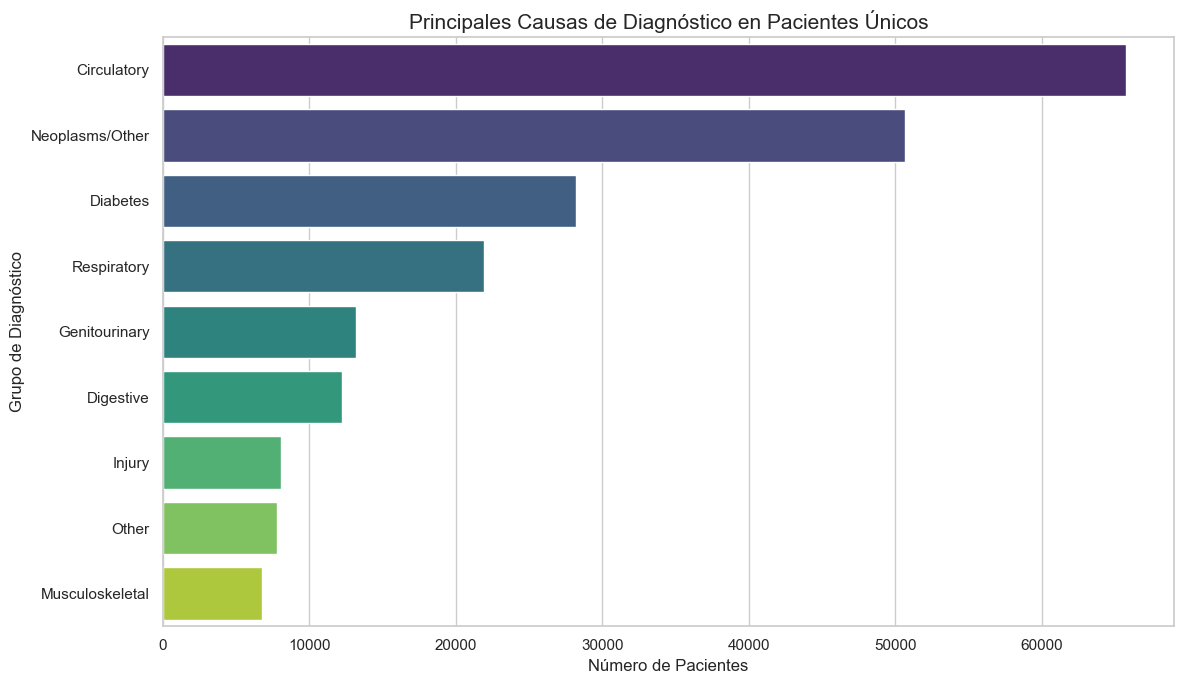

In [5]:
# 1. Eliminamos duplicados de pacientes para quedarnos con el perfil único
df_unique_patients = df.drop_duplicates(subset=['patient_nbr'])

# 2. Consolidamos los diagnósticos. Vamos a derretir (melt) las tres columnas 
# para contar la frecuencia total de cada grupo diagnóstico por paciente.
diag_cols = ['diag_1_group', 'diag_2_group', 'diag_3_group']
df_diags = df_unique_patients[diag_cols].melt(var_name='posicion', value_name='diagnostico')

# 3. Contamos las frecuencias
diag_counts = df_diags['diagnostico'].value_counts().reset_index()
diag_counts.columns = ['Grupo Diagnóstico', 'Frecuencia']

# 4. Graficamos
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")
sns.barplot(data=diag_counts, x='Frecuencia', y='Grupo Diagnóstico', hue='Grupo Diagnóstico', palette='viridis', legend=False)

plt.title('Principales Causas de Diagnóstico en Pacientes Únicos', fontsize=15)
plt.xlabel('Número de Pacientes', fontsize=12)
plt.ylabel('Grupo de Diagnóstico', fontsize=12)

plt.tight_layout()
plt.show()

Eje Y (Grupo de Diagnóstico): Muestra las categorías agrupadas (como Circulatorio, Respiratorio, Diabetes, etc.). Estas categorías provienen de la combinación de los diagnósticos primarios, secundarios y terciarios.

Eje X (Número de Pacientes): Indica a cuántos individuos únicos se les asignó ese diagnóstico al menos una vez en cualquiera de sus tres posiciones de diagnóstico.

Interpretación: permite identificar rápidamente cuál es la comorbilidad predominante. Por ejemplo, si "Circulatorio" es la barra más larga, significa que la mayoría de tus pacientes diabéticos también sufren de problemas cardíacos o vasculares.

In [6]:
print("------- Dimensión del dataframe principal -------")
print(df
.shape)

------- Dimensión del dataframe principal -------
(101766, 26)


## Dias de internación por DIagnostico

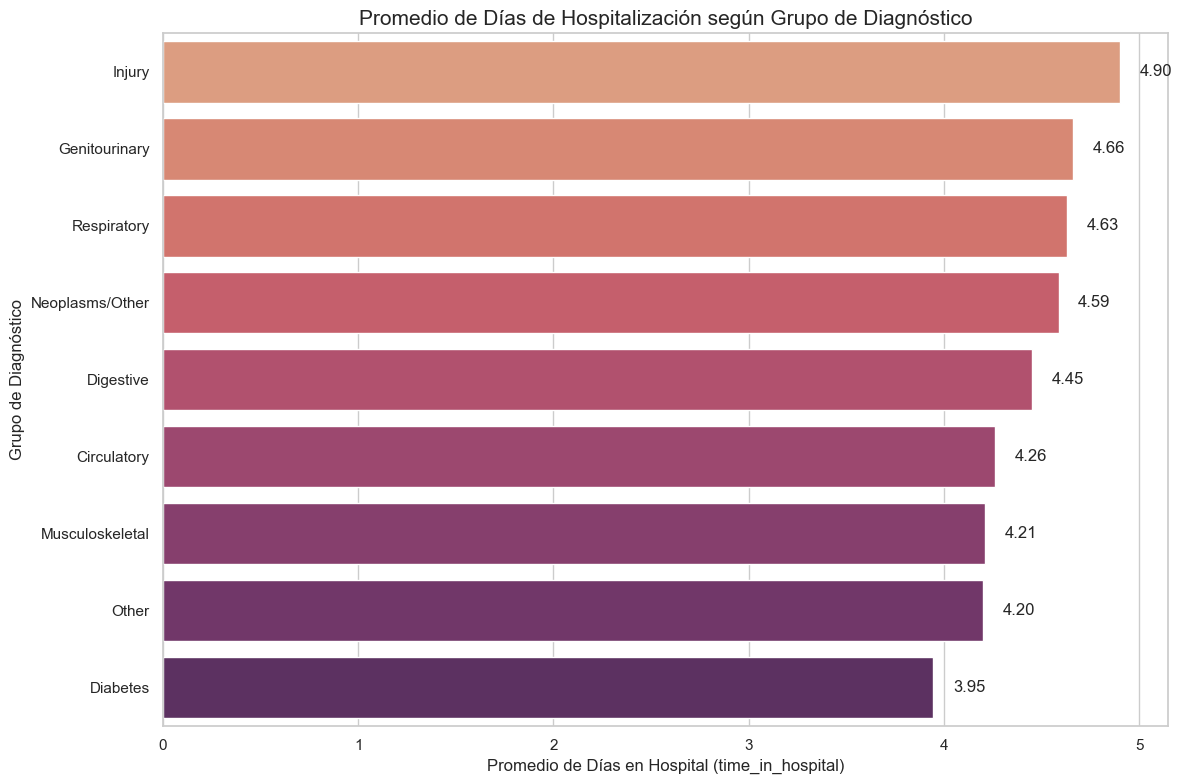

In [7]:
# 1. "Derretimos" el dataframe para tener una columna de diagnóstico y su tiempo de hospitalización asociado
diag_cols = ['diag_1_group', 'diag_2_group', 'diag_3_group']
df_melted = df.melt(id_vars=['time_in_hospital'], 
                    value_vars=diag_cols, 
                    var_name='posicion_diag', 
                    value_name='grupo_diagnostico')

# 2. Calculamos el promedio de tiempo en hospital por grupo de diagnóstico
# Ordenamos de mayor a menor para facilitar la lectura
avg_time_diag = df_melted.groupby('grupo_diagnostico')['time_in_hospital'].mean().sort_values(ascending=False).reset_index()

# 3. Graficamos
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")
sns.barplot(data=avg_time_diag, x='time_in_hospital', y='grupo_diagnostico', hue='grupo_diagnostico', palette='flare', legend=False)

plt.title('Promedio de Días de Hospitalización según Grupo de Diagnóstico', fontsize=15)
plt.xlabel('Promedio de Días en Hospital (time_in_hospital)', fontsize=12)
plt.ylabel('Grupo de Diagnóstico', fontsize=12)

# Añadimos el valor exacto al final de cada barra para mayor precisión
for index, row in avg_time_diag.iterrows():
    plt.text(row.time_in_hospital + 0.1, index, f'{row.time_in_hospital:.2f}', va='center')

plt.tight_layout()
plt.show()

Eje Y (Grupo de Diagnóstico): Lista todas las categorías diagnósticas presentes en las tres columnas (diag_1, diag_2, diag_3).

Eje X (Promedio de Días): Representael tiempo que los pacientes con esa patología permanecieron internados.

Hallazgo: Las lesiones (Injury) son las que más tiempo de internación requieren, con casi 5 días de promedio. Por el contrario, cuando la Diabetes es el diagnóstico principal, la estancia es la más corta (3.95 días).

Interpretación: No todas las enfermedades ocupan la cama el mismo tiempo. Mientras que los cuadros quirúrgicos o de lesiones estiran la internación, las patologías metabólicas como la diabetes se resuelven o estabilizan más rápido en promedio.


## Grafico 1 Boxplot - Tiempo de hospitalizacion por genero
## Grafico 2 Barplot - Tiempo de hospitalizacion por edad

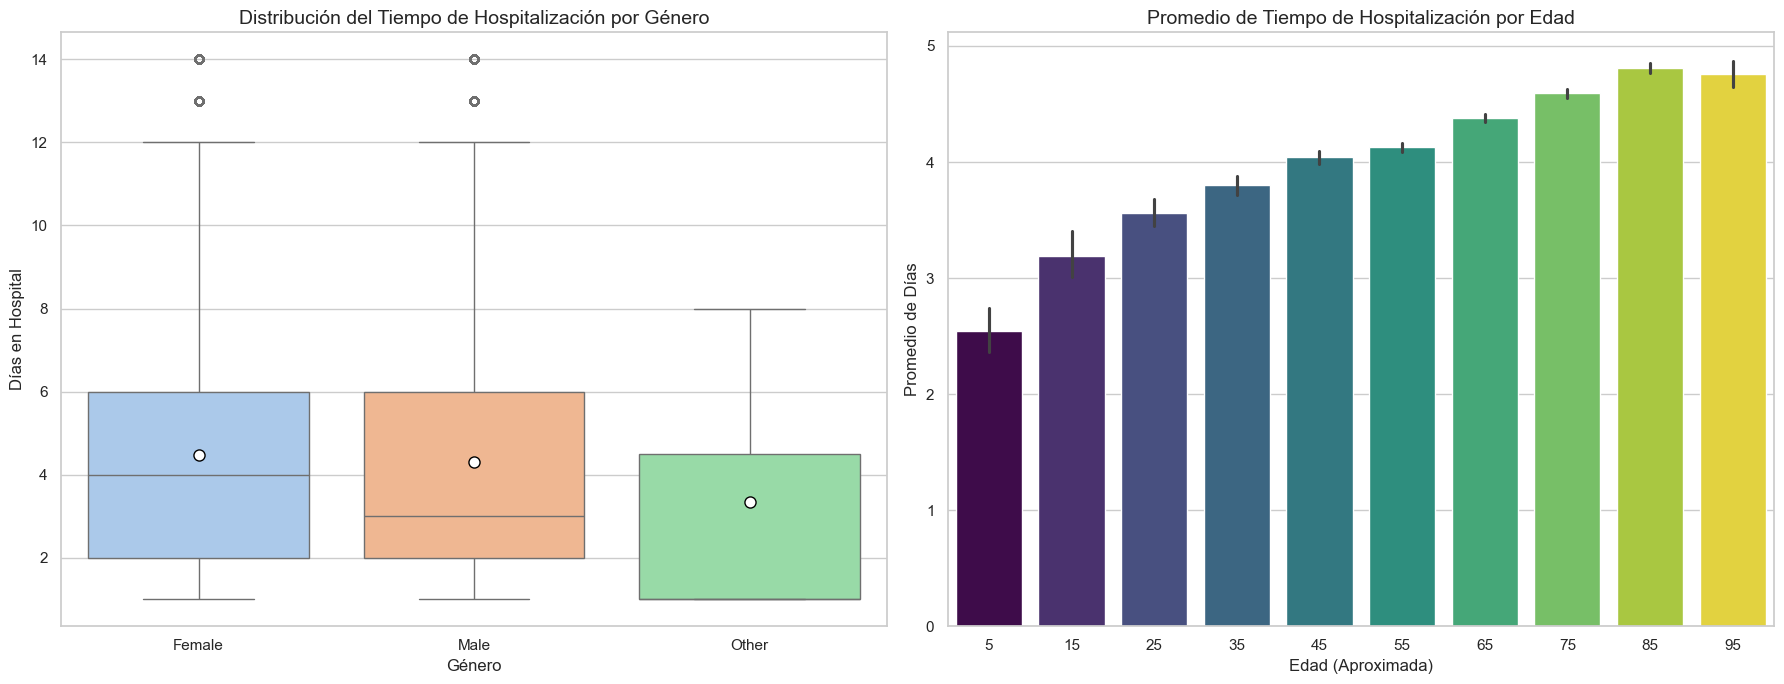

In [8]:
# Creamos una figura con dos subplots para comparar lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
sns.set_theme(style="whitegrid")

# 1. Gráfico por Género (Boxplot para ver distribución y promedio)
sns.boxplot(data=df, x='gender', y='time_in_hospital', hue='gender',legend=False, ax=ax1, palette='pastel', showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})
ax1.set_title('Distribución del Tiempo de Hospitalización por Género', fontsize=14)
ax1.set_xlabel('Género', fontsize=12)
ax1.set_ylabel('Días en Hospital', fontsize=12)

# 2. Gráfico por Grupo de Edad (Barplot para ver la tendencia clara)
# Ordenamos las edades para que el gráfico tenga sentido cronológico
age_order = sorted(df['age_numeric'].unique())
sns.barplot(data=df, x='age_numeric', hue='age_numeric', y='time_in_hospital', legend=False, ax=ax2, palette='viridis', order=age_order)
ax2.set_title('Promedio de Tiempo de Hospitalización por Edad', fontsize=14)
ax2.set_xlabel('Edad (Aproximada)', fontsize=12)
ax2.set_ylabel('Promedio de Días', fontsize=12)

plt.tight_layout()
plt.show()

## Grafico 1
Eje x: divide a los pacientes en femenino, masculinos y otros.
Eje y: muestra los dias que pasaron en el hospital

Hallazgo: Las mujeres y los hombres pasan dias similares internados, cerca de los 4 dias, aunque las mujeres presentan algunos casos aislados de estancias mas largas

EL genero no es un factor que cambie demasiado cuanto se queda alguien en el hospital, el comportamiento es igual en los tres casos
aunque podemos identificar algunos outliers de casos excepcionales de pacientes que estuvieron mas dias que el promedio cuando lo normal es quedarse entre 2 y 6 dias.

## GRafico 2
Eje x: muestra la edad aproximada del paciente
Eje y: muestra el promedio de dias de internación

Hallazgo: a medida que aumenta la edad, aumenta el tiempo de internación. Un niño de 5 años está unos 2.5 días, mientras que un adulto mayor de 85 años está casi 5 días.

La edad es un predictor directo del tiempo de cama. Cuanto más grande es el paciente, más lento es el proceso para darle el alta.


## Este gráfico de dispersión nos permite observar la densidad y el comportamiento

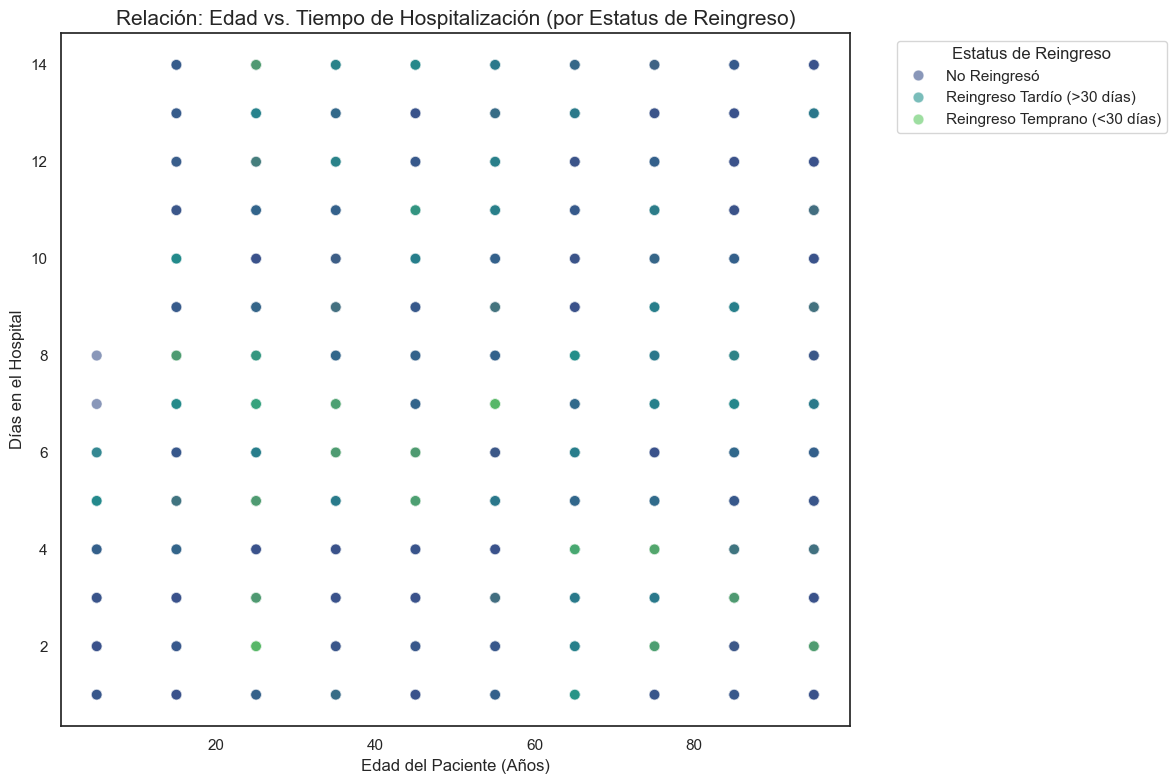

In [9]:
# Configuramos el estilo
plt.figure(figsize=(12, 8))
sns.set_theme(style="white")

# Creamos el gráfico de dispersión
# Usamos 'hue' para los reingresos y 'alpha' para manejar la superposición de puntos
scatter = sns.scatterplot(
    data=df, 
    x='age_numeric', 
    y='time_in_hospital', 
    hue='readmitted_status', 
    palette='viridis',
    alpha=0.6,
    s=60 # Tamaño de los puntos
)

plt.title('Relación: Edad vs. Tiempo de Hospitalización (por Estatus de Reingreso)', fontsize=15)
plt.xlabel('Edad del Paciente (Años)', fontsize=12)
plt.ylabel('Días en el Hospital', fontsize=12)
plt.legend(title='Estatus de Reingreso', bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustamos para que no se corte la leyenda
plt.tight_layout()
plt.show()

Eje x: edad de pacientes en años
EJe y: dias de estada en el hospital

Este gráfico sirve para ver los casos. Aunque la mayoría se concentra abajo (pocos días), permite detectar visualmente que los pacientes de todas las edades pueden reingresar, pero solo los más grandes suelen alcanzar los tiempos de internación más largos.

## Histograma de distribución de la duración de la hospitalizacion

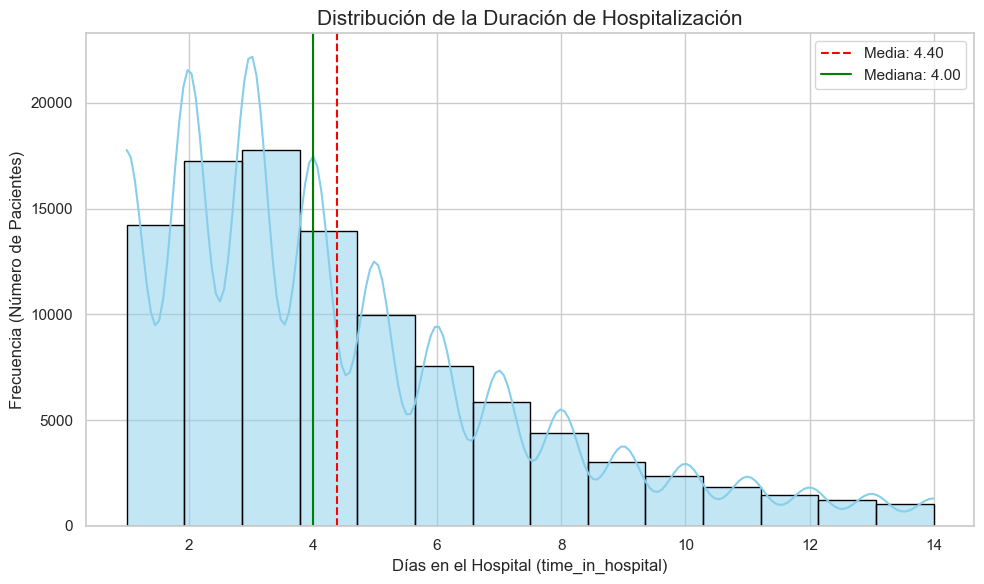

In [10]:
# Configuramos el estilo
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Creamos el histograma
sns.histplot(data=df, x='time_in_hospital', bins=14, kde=True, color='skyblue', edgecolor='black')

# Añadimos detalles estadísticos para enriquecer el gráfico
plt.axvline(df['time_in_hospital'].mean(), color='red', linestyle='--', label=f"Media: {df['time_in_hospital'].mean():.2f}")
plt.axvline(df['time_in_hospital'].median(), color='green', linestyle='-', label=f"Mediana: {df['time_in_hospital'].median():.2f}")

plt.title('Distribución de la Duración de Hospitalización', fontsize=15)
plt.xlabel('Días en el Hospital (time_in_hospital)', fontsize=12)
plt.ylabel('Frecuencia (Número de Pacientes)', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

Eje x: muestra los dias que el paciente estuvo internado
Eje y: muestra la cantidad de pacientes, mientras mas es la altura de la barra mas apacienes se fueron en esos dias.

Hallazgo: la gran mayoria de los pacientes se va a su casa rapido entre el segundo y el cuarto dia, despues del sexto dia quedan muy pocos pacientes internados.


Grafixxx

## Reingreso y Tratamiento Hospitalario


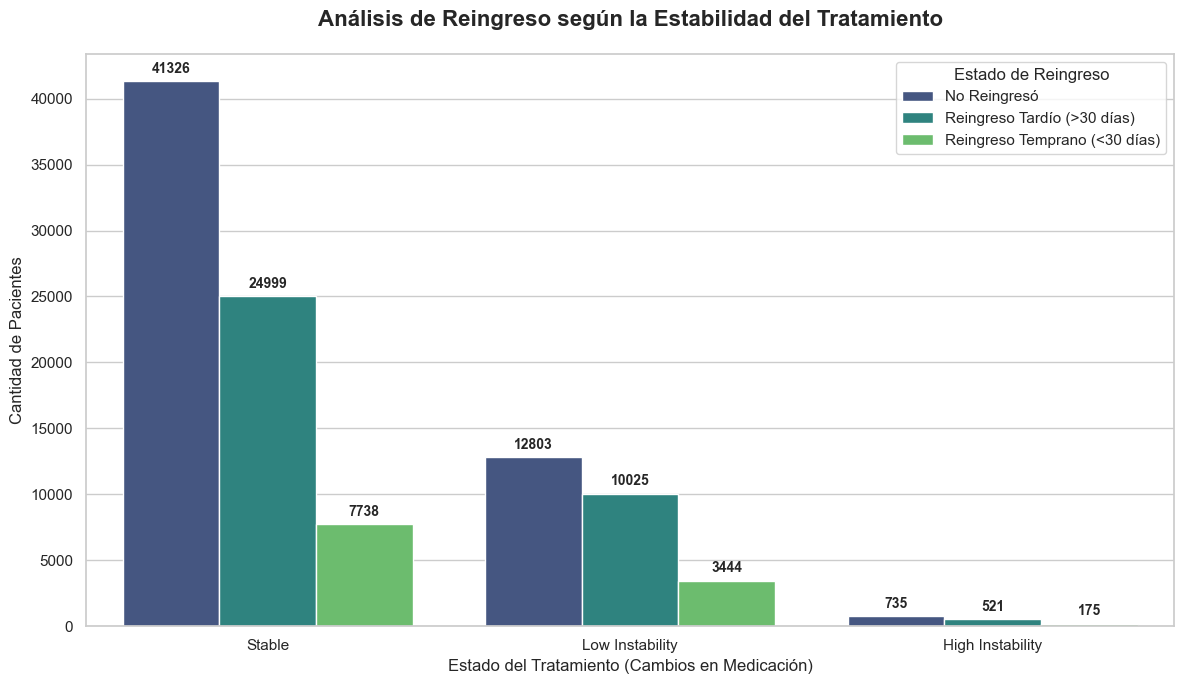

In [11]:
# 1. Configuración de estilo y tamaño
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# 2. Creación del gráfico de barras
# Usamos 'treatment_status' vs 'readmitted_status'
ax = sns.countplot(
    data=df, 
    x='treatment_status', 
    hue='readmitted_status',
    palette='viridis', 
    order=['Stable', 'Low Instability', 'High Instability']
)

# 3. Personalización del gráfico
plt.title('Análisis de Reingreso según la Estabilidad del Tratamiento', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Estado del Tratamiento (Cambios en Medicación)', fontsize=12)
plt.ylabel('Cantidad de Pacientes', fontsize=12)
plt.legend(title='Estado de Reingreso', loc='upper right')

# 4. Etiquetas de valor sobre cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=10,
                    fontweight='bold')

plt.tight_layout()
plt.show()

Eje x: divide los pacientes segun que tanto cambió su medicación
Eje y: La cantidad de pacientes

Hallazgo: cuanto mas estable es el tratamiento ( menos cambios en los remedios ) mas probable es que el paciente sea dado de alta y no tenga que volver de manera temprana

Interpretación: si un paciente tiene muchos cambios de medicación durante sus dias de estada, el riesgo de que regrese al hospital es mayor. Los pacientes con tratamientos mas estables son los que mejor evolucionan tras el alta.

## Grafico para StoryTelling

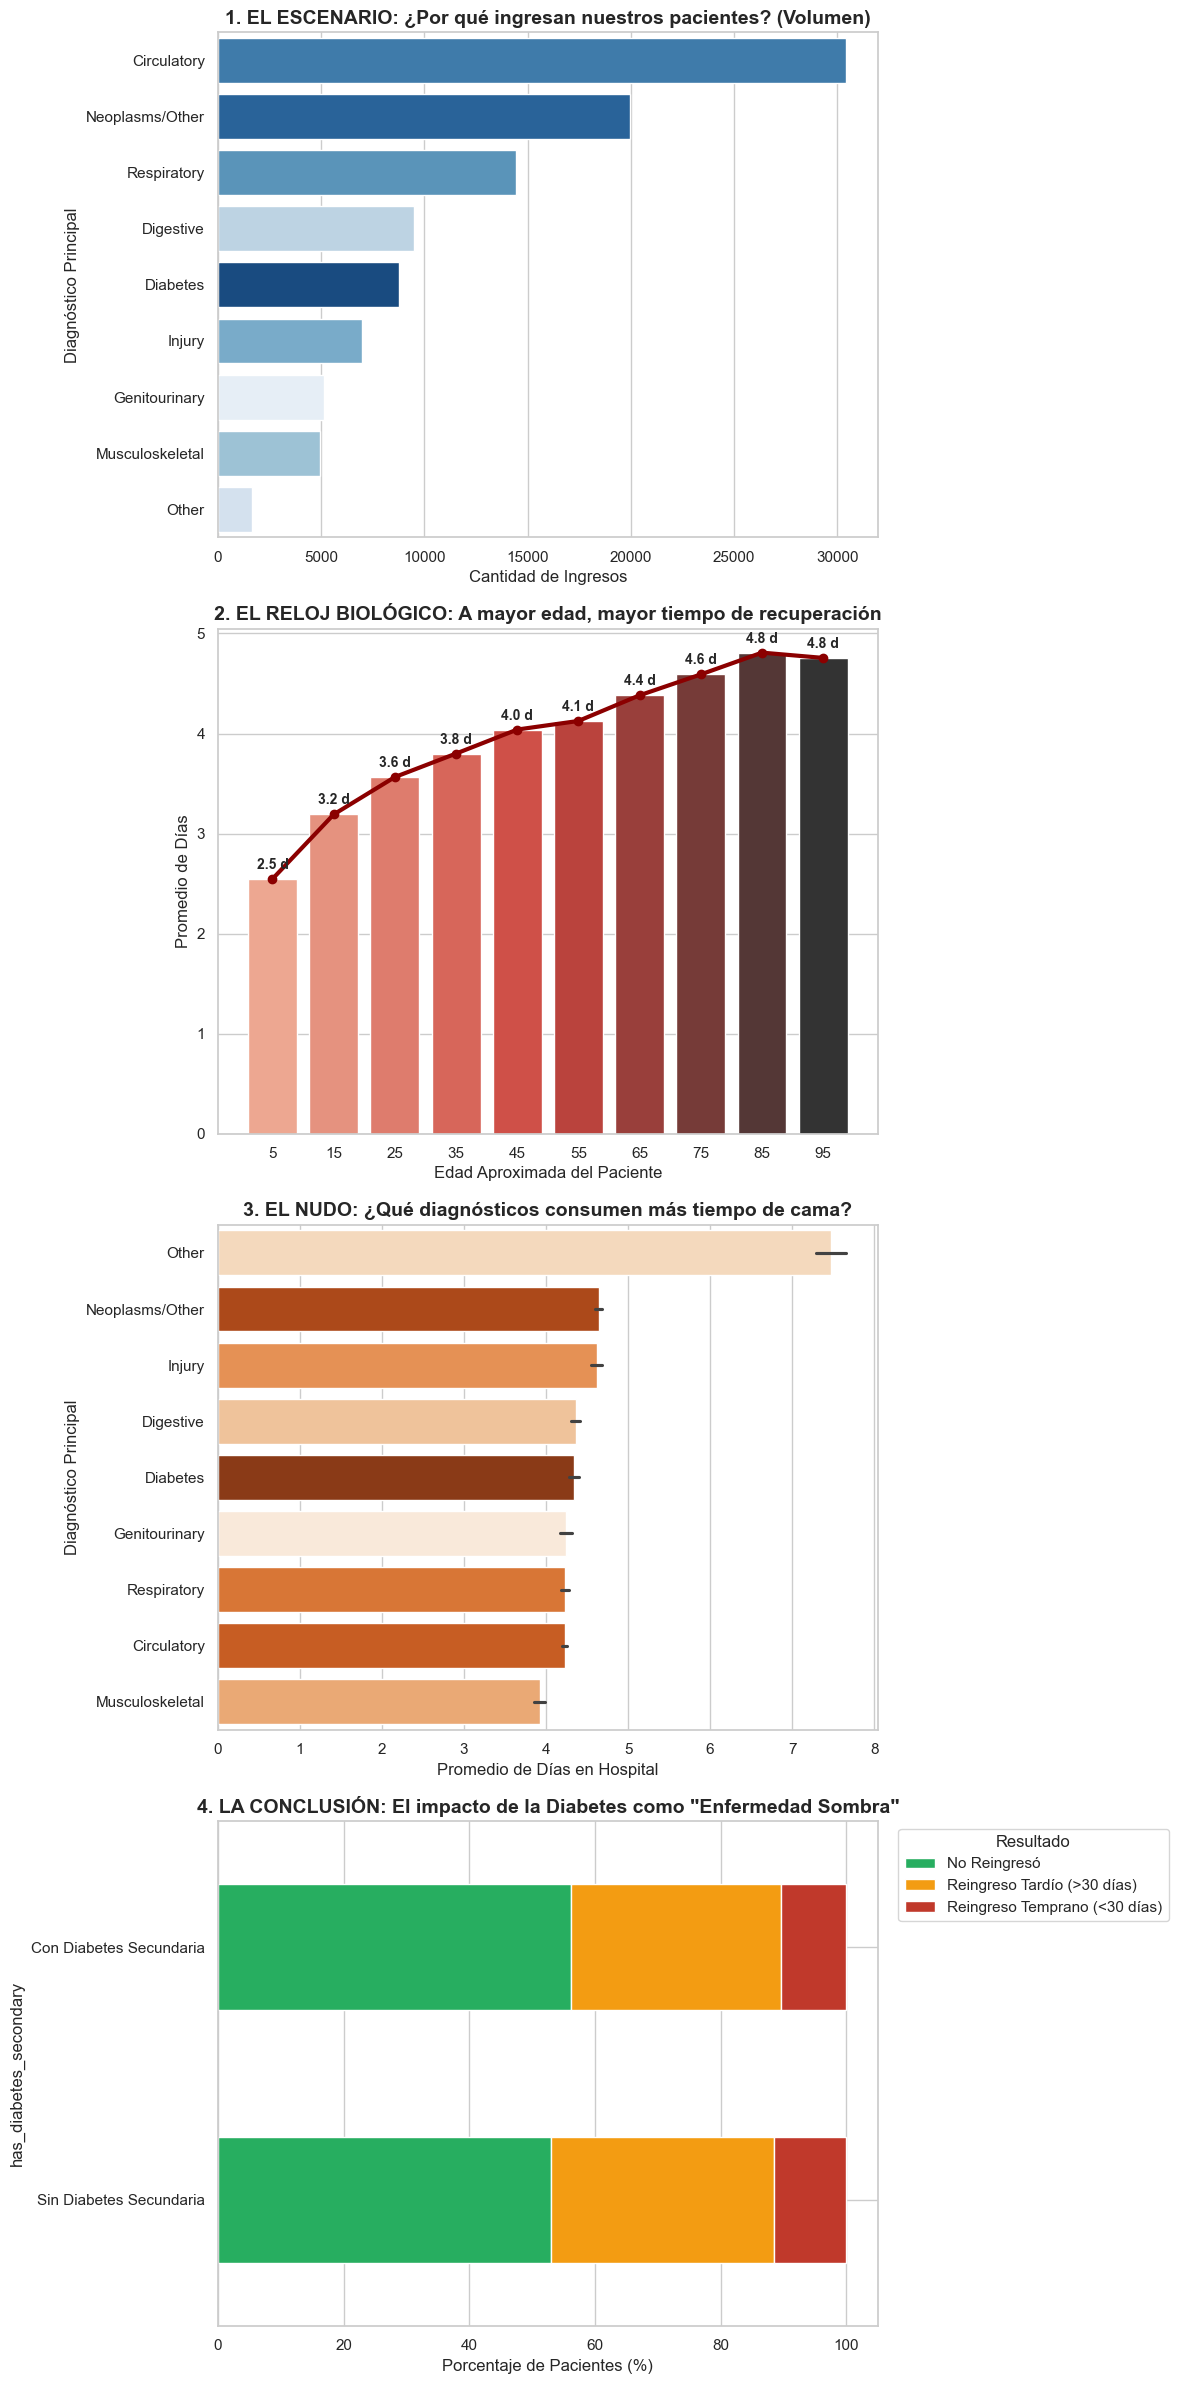

In [13]:

sns.set_theme(style="whitegrid")

# Configuramos una figura con 4 gráficos verticales (ajustamos el alto a 24 para que cada uno mida 6)
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 24))

# --- GRÁFICO 1: EL ESCENARIO (Volumen) ---
diag_order = df['diag_1_group'].value_counts().index
sns.countplot(data=df, y='diag_1_group', hue='diag_1_group', legend=False, ax=ax1, order=diag_order, palette='Blues_r')
ax1.set_title('1. EL ESCENARIO: ¿Por qué ingresan nuestros pacientes? (Volumen)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Cantidad de Ingresos')
ax1.set_ylabel('Diagnóstico Principal')

# --- GRÁFICO 2: EL RELOJ BIOLÓGICO (Edad) ---
age_avg_time = df.groupby('age_numeric')['time_in_hospital'].mean().reset_index()
sns.barplot(data=age_avg_time, x='age_numeric', y='time_in_hospital', hue='age_numeric', legend=False, ax=ax2, palette='Reds_d')
# Línea de tendencia sobre las barras
ax2.plot(range(len(age_avg_time)), age_avg_time['time_in_hospital'], marker='o', color='darkred', linewidth=3)
ax2.set_title('2. EL RELOJ BIOLÓGICO: A mayor edad, mayor tiempo de recuperación', fontsize=14, fontweight='bold')
ax2.set_xlabel('Edad Aproximada del Paciente')
ax2.set_ylabel('Promedio de Días')
for i, val in enumerate(age_avg_time['time_in_hospital']):
    ax2.text(i, val + 0.1, f'{val:.1f} d', ha='center', fontsize=10, fontweight='bold')

# --- GRÁFICO 3: EL COSTO (Tiempo por Diagnóstico) ---
avg_stay = df.groupby('diag_1_group')['time_in_hospital'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='time_in_hospital', y='diag_1_group', hue='diag_1_group', legend=False, ax=ax3, order=avg_stay, palette='Oranges_r')
ax3.set_title('3. EL NUDO: ¿Qué diagnósticos consumen más tiempo de cama?', fontsize=14, fontweight='bold')
ax3.set_xlabel('Promedio de Días en Hospital')
ax3.set_ylabel('Diagnóstico Principal')

# --- GRÁFICO 4: EL DESENLACE (Diabetes Secundaria) ---
df['has_diabetes_secondary'] = ((df['diag_2_group'] == 'Diabetes') | (df['diag_3_group'] == 'Diabetes'))
reingreso_diabetes = pd.crosstab(df['has_diabetes_secondary'], df['readmitted_status'], normalize='index') * 100
reingreso_diabetes.plot(kind='barh', stacked=True, ax=ax4, color=['#27ae60', '#f39c12', '#c0392b'])
ax4.set_title('4. LA CONCLUSIÓN: El impacto de la Diabetes como "Enfermedad Sombra"', fontsize=14, fontweight='bold')
ax4.set_yticklabels(['Sin Diabetes Secundaria', 'Con Diabetes Secundaria'])
ax4.set_xlabel('Porcentaje de Pacientes (%)')
ax4.legend(title='Resultado', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Segmentación de Estancia Por Diagnostico Principal

<Figure size 1200x800 with 0 Axes>

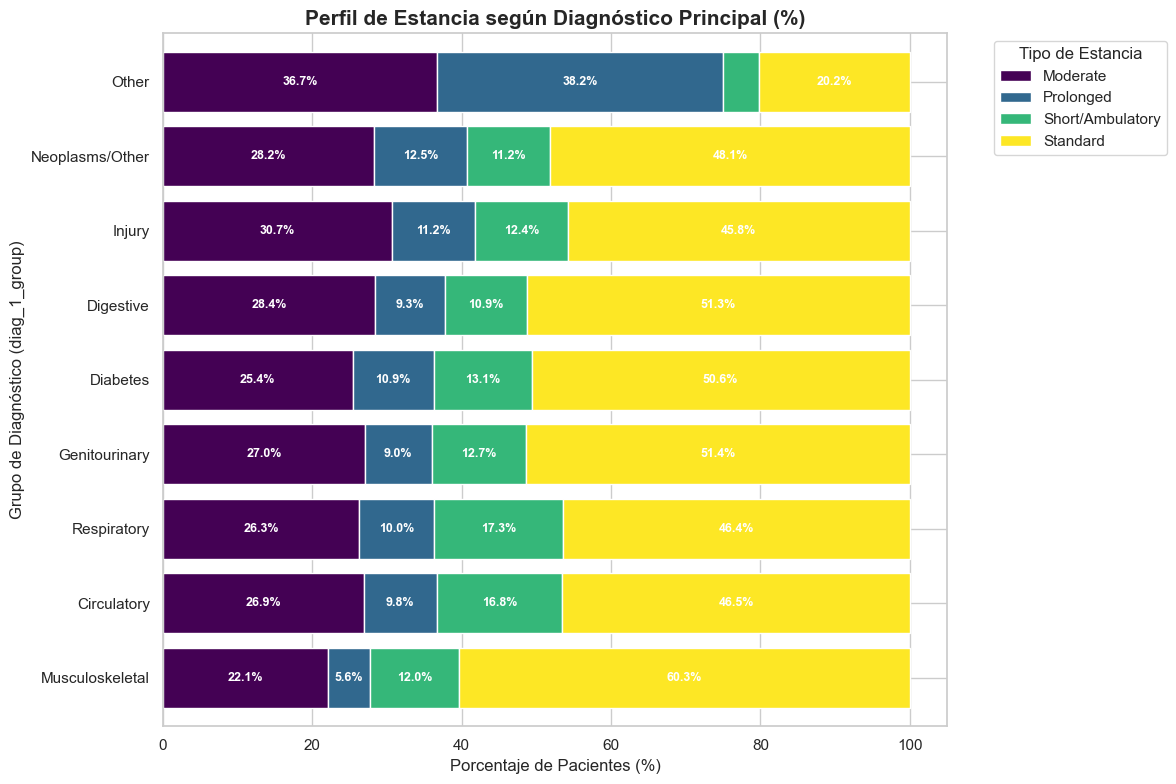

In [14]:
sns.set_theme(style="whitegrid")

# 1. Creamos la tabla cruzada normalizada al 100% por diagnóstico
# Esto nos permite ver qué porcentaje de cada enfermedad cae en cada tipo de estancia
ct_perc = pd.crosstab(df['diag_1_group'], df['hospital_stay_type'], normalize='index') * 100

# 2. Ordenamos los diagnósticos por el promedio de tiempo para que tenga coherencia visual
sort_order = df.groupby('diag_1_group')['time_in_hospital'].mean().sort_values().index
ct_perc = ct_perc.reindex(sort_order)

# 3. Graficamos
plt.figure(figsize=(12, 8))

# Graficamos las barras apiladas
ax = ct_perc.plot(kind='barh', stacked=True, figsize=(12, 8), 
                  colormap='viridis', width=0.8)

# Estética del gráfico
plt.title('Perfil de Estancia según Diagnóstico Principal (%)', fontsize=15, fontweight='bold')
plt.xlabel('Porcentaje de Pacientes (%)', fontsize=12)
plt.ylabel('Grupo de Diagnóstico (diag_1_group)', fontsize=12)
plt.legend(title='Tipo de Estancia', bbox_to_anchor=(1.05, 1), loc='upper left')

# Añadimos etiquetas de porcentaje dentro de las barras (solo si el segmento es visible)
for p in ax.patches:
    width = p.get_width()
    if width > 5: # Solo mostrar texto si el segmento es mayor al 5%
        x, y = p.get_xy() 
        ax.text(x + width/2, y + 0.5*p.get_height(), f'{width:.1f}%', 
                va='center', ha='center', color='white', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

Eje y: grupos de enfermedades
Eje x: % de pacientes segun dias de estada

Hallazgo: en casi todas las enfermedades, la mayoría tiene una estancia Estándar (amarillo), pero en la categoría "Other", el 38% de los pacientes tiene estancias muy largas (azul).

La mayoría de las enfermedades son "predecibles", pero los casos complejos (Otros) son los que más riesgo tienen de ocupar la cama por mucho tiempo.



## Mapa de calor relacion de la gravedad del paciente

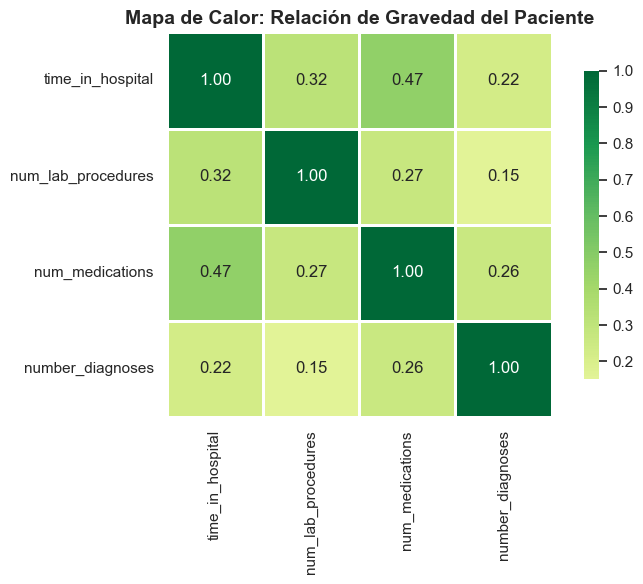

In [16]:


# 1. Seleccionamos solo las 4 variables de "esfuerzo médico"
# Son fáciles de entender para cualquier persona (Tiempo, Labs, Medicinas, Diagnósticos)
simple_corr_cols = [
    'time_in_hospital', 
    'num_lab_procedures', 
    'num_medications', 
    'number_diagnoses'
]

# 2. Calculamos la correlación
corr_matrix = df[simple_corr_cols].corr()

# 3. Graficamos
plt.figure(figsize=(8, 6))
sns.set_theme(style="white")

sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='RdYlGn', # Rojo (bajo) a Verde (alto) para que sea muy visual
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": .8}
)

plt.title('Mapa de Calor: Relación de Gravedad del Paciente', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Ambos ejes (x:y): Comparan las mismas cuatro variables entre sí: tiempo en el hospital, cantidad de procedimientos de laboratorio, cantidad de medicamentos y número de diagnósticos.

Hallazgo: la relación más fuerte (fuera de las variables comparadas consigo mismas) es de 0.47, y se da entre el tiempo en el hospital y la cantidad de medicamentos.

Lo que más influye en que un paciente se quede muchos días internado es la cantidad de remedios distintos que recibe. Los estudios de laboratorio y la cantidad de diagnósticos tienen mucha menos relación con el tiempo que el paciente ocupa la cama.
